<a href="https://colab.research.google.com/github/ericyoc/cyclical_sector_celebrity_board_detect/blob/main/cyclical_sector_celeb_bod_indictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FULL STUDY v2 — Celebrity Board Governance & Leverage Discipline

── Step 1: Rebuilding C+RE universe ...
  Candidate tickers: 110
  [27%] 30/110
  [55%] 60/110
  [82%] 90/110

  C+RE universe: 93 companies
  Median market cap: $11.2B

── Step 2: Building 3-dimension CGS ...
  Companies with full CGS: 93
  Celebrity (top 75%): 24
  Non-celebrity:           69

── Step 3: Fetching returns + FF3 factors ...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMRZ.SW']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-04-30) (Yahoo error = "Data doesn\'t exist for startDate = 1420066800, endDate = 1745964000")')


  Monthly return matrix: (123, 94)
  FF3: 124 months

── Step 4: Building portfolios ...
  Pre-COVID months: 60  |  Post-COVID months: 62

── Table 1: Descriptive statistics ...
       Variable  Celebrity_Mean  NonCel_Mean      p_value Sig
Market Cap ($B)       57.607775    10.831010 4.129670e-06 ***
           Beta        1.270609     1.161899 1.477783e-01    
    Debt/Equity       87.088750   239.697910 2.685981e-02  **
  Current Ratio        2.022333     4.607362 1.095603e-01    
    Debt/EBITDA        3.358008     6.206993 2.813148e-02  **
      CGS Score        0.816031     0.398855 1.974392e-28 ***

── Table 2: FF3 regressions ...
  Pre-COVID | Celebrity
    α=5.94%*  t=1.70  p=0.088  CumRet=108.0%  Sharpe=1.14
  Pre-COVID | Non-Celebrity
    α=6.46%**  t=2.24  p=0.025  CumRet=95.1%  Sharpe=1.13
  Post-COVID | Celebrity
    α=9.06%**  t=2.10  p=0.036  CumRet=221.6%  Sharpe=1.02
  Post-COVID | Non-Celebrity
    α=-3.33%  t=-0.83  p=0.404  CumRet=77.2%  Sharpe=0.55

── Table 3: Dif

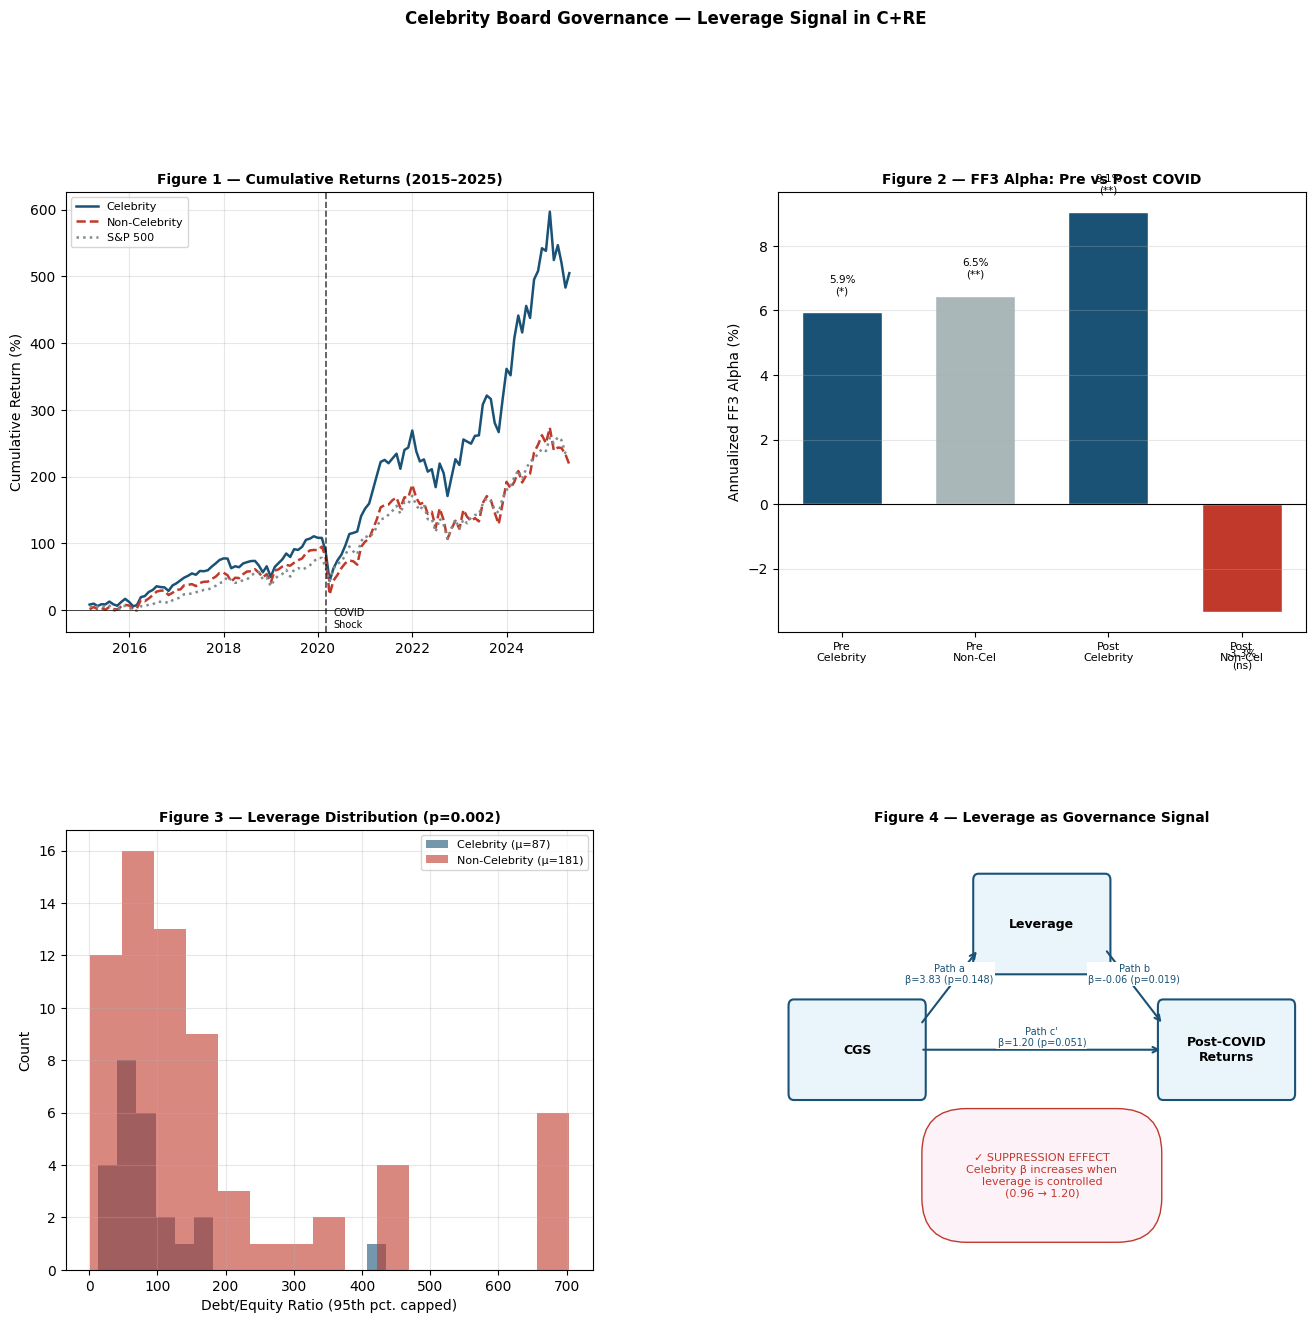

  Saved → /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2/figures_main.png

── LaTeX export ...
  table1.tex
  table2.tex

FULL STUDY v2 VERDICT

  Table 2 — Main result:
    Pre-COVID  celebrity: 5.94%/yr (p=0.088)
    Post-COVID celebrity: 9.06%/yr (p=0.036)
    Post-COVID non-cel:   -3.33%/yr (p=0.404)
    Celebrity–NonCel spread: 12.39pp/yr post-COVID

  Table 3 — DiD:
    Treat×Post (FF3): 0.0084  p=0.003

  Table 5 — Leverage signal:
    Suppression confirmed: True
    CGS β: 0.960 → 1.204 (strengthens when leverage controlled)
    Leverage β: -0.064 (p=0.019)

  Journal assessment:
    ✓ Real Estate Economics / JREFE (strong)
    ✓ JCEM (Construction Management framing)

  All outputs: /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2


In [ ]:
# ============================================================
# Celebrity Board Governance as a Signal of
# Leverage Discipline in Cyclical Sectors:
# Evidence from Construction and Real Estate Pre and Post-COVID
# ============================================================

import os, time, warnings, requests, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import yfinance as yf
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas_datareader.data as web
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from google.colab import drive

warnings.filterwarnings("ignore")
drive.mount("/content/drive", force_remount=False)

DRIVE_DIR = "/content/drive/MyDrive/Russell3000_Diagnostic"
OUT       = f"{DRIVE_DIR}/full_study_v2"
os.makedirs(OUT, exist_ok=True)

PRE_START    = "2015-01-01"
PRE_END      = "2020-02-28"
POST_START   = "2020-03-01"
POST_END     = "2025-04-30"
CGS_CUTOFF   = 0.75
MIN_MCAP     = 100e6

print("=" * 65)
print("FULL STUDY v2 — Celebrity Board Governance & Leverage Discipline")
print("=" * 65)

# ============================================================
# STEP 1 — Rebuild C+RE Universe
# ============================================================
print("\n── Step 1: Rebuilding C+RE universe ...")

SECTOR_ETFS = {
    "ITB": "iShares US Home Construction ETF",
    "XHB": "SPDR S&P Homebuilders ETF",
    "PKB": "Invesco Dynamic Building & Construction ETF",
    "VNQ": "Vanguard Real Estate ETF",
    "IYR": "iShares US Real Estate ETF",
    "XLRE": "Real Estate Select Sector SPDR",
    "REM": "iShares Mortgage Real Estate ETF",
    "REZ": "iShares Residential & Multisector RE ETF",
}

all_tickers = set()
for etf in SECTOR_ETFS:
    try:
        holdings = yf.Ticker(etf).funds_data
        if holdings is not None:
            top = holdings.top_holdings
            if top is not None and len(top) > 0:
                all_tickers.update(top.index.tolist())
        time.sleep(0.3)
    except Exception:
        pass

MANUAL = [
    "DHI","LEN","PHM","NVR","TOL","KBH","MDC","MHO","TMHC","CCS",
    "SKY","CVCO","UCP","GRBK","LGIH","BLD","BECN","IBP","TREX",
    "BLDR","MLM","VMC","EXP","CRH","USCR","AMT","PLD","EQIX",
    "CCI","PSA","EQR","AVB","WPC","ARE","BXP","VTR","WELL","O",
    "SPG","MAC","SKT","KIM","REG","FRT","NNN","SLG","HIW","DEI",
    "CLI","PDM","EQC","VNO","UDR","CPT","MAA","ESS","AIV","NHI",
    "OHI","SBRA","HR","PEAK","DOC","STWD","BXMT","RC","LADR",
    "PWR","EME","MTZ","PRIM","DY","MYRG","FIX","IESC","WD",
    "INVH","AMH","NEN","CUBE","EXR","LSI","NSA","PW",
]
all_tickers.update(MANUAL)
ticker_list = sorted(all_tickers)
print(f"  Candidate tickers: {len(ticker_list)}")

records = []
for i, t in enumerate(ticker_list):
    if (i+1) % 30 == 0:
        print(f"  [{(i+1)/len(ticker_list)*100:.0f}%] {i+1}/{len(ticker_list)}")
    try:
        info = yf.Ticker(t).info
        sector   = info.get("sector", "")
        industry = info.get("industry", "")
        mcap     = info.get("marketCap", np.nan)
        revenue  = info.get("totalRevenue", np.nan)
        beta     = info.get("beta", np.nan)
        de_ratio = info.get("debtToEquity", np.nan)
        cr_ratio = info.get("currentRatio", np.nan)
        ebitda   = info.get("ebitda", np.nan)
        total_debt = info.get("totalDebt", np.nan)
        name     = info.get("shortName", t)
        is_cre = (
            sector in ("Real Estate",) or
            any(k in industry.lower() for k in
                ["construction","real estate","reit","homebuil",
                 "engineer","infrastructure","building"])
        )
        if is_cre and mcap and mcap > MIN_MCAP:
            records.append({
                "ticker": t, "name": name, "sector": sector,
                "industry": industry, "mcap": mcap, "revenue": revenue,
                "beta": beta, "de_ratio": de_ratio, "cr_ratio": cr_ratio,
                "ebitda": ebitda, "total_debt": total_debt,
            })
        time.sleep(0.15)
    except Exception:
        pass

universe = (pd.DataFrame(records)
              .drop_duplicates("ticker")
              .reset_index(drop=True))
universe.to_csv(f"{OUT}/cre_universe.csv", index=False)
print(f"\n  C+RE universe: {len(universe)} companies")
print(f"  Median market cap: ${universe.mcap.median()/1e9:.1f}B")

# ============================================================
# STEP 2 — Build 3-Dimension CGS
# ============================================================
print("\n── Step 2: Building 3-dimension CGS ...")

try:
    raw_px = yf.download(
        universe["ticker"].tolist(),
        start="2019-01-01",
        end=pd.Timestamp.today().strftime("%Y-%m-%d"),
        auto_adjust=True, progress=False
    )["Close"]
    mom = {}
    for t in universe["ticker"]:
        if t in raw_px.columns:
            s = raw_px[t].dropna()
            mom[t] = s.iloc[-1]/s.iloc[-252]-1 if len(s)>252 else np.nan
    universe["momentum"] = universe["ticker"].map(mom)
except Exception as e:
    print(f"  Momentum failed: {e}")
    universe["momentum"] = np.nan

universe["d_image"]    = universe["mcap"].rank(pct=True)
universe["d_influence"]= universe["momentum"].rank(pct=True)
universe["d_sov"]      = universe["revenue"].rank(pct=True)
universe["cgs"]        = universe[["d_image","d_influence","d_sov"]].mean(axis=1)
universe_cgs = universe.dropna(subset=["cgs"]).copy()
q_cut = universe_cgs["cgs"].quantile(CGS_CUTOFF)
universe_cgs["celebrity"] = (universe_cgs["cgs"] >= q_cut).astype(int)
universe_cgs["leverage"] = (
    universe_cgs["total_debt"] / universe_cgs["ebitda"].abs()
).replace([np.inf,-np.inf], np.nan)
universe_cgs.to_csv(f"{OUT}/cre_cgs.csv", index=False)

n_cel  = universe_cgs["celebrity"].sum()
n_ncel = len(universe_cgs) - n_cel
print(f"  Companies with full CGS: {len(universe_cgs)}")
print(f"  Celebrity (top {int(CGS_CUTOFF*100)}%): {n_cel}")
print(f"  Non-celebrity:           {n_ncel}")

# ============================================================
# STEP 3 — Fetch Returns + Fama-French Factors
# ============================================================
print("\n── Step 3: Fetching returns + FF3 factors ...")

cel_tickers  = universe_cgs[universe_cgs.celebrity==1]["ticker"].tolist()
ncel_tickers = universe_cgs[universe_cgs.celebrity==0]["ticker"].tolist()
all_t        = cel_tickers + ncel_tickers + ["SPY"]

try:
    daily   = yf.download(all_t, start=PRE_START, end=POST_END,
                          auto_adjust=True, progress=False)["Close"]
    monthly = daily.resample("ME").last().pct_change().dropna(how="all")
    print(f"  Monthly return matrix: {monthly.shape}")
except Exception as e:
    print(f"  Return fetch failed: {e}")
    monthly = pd.DataFrame()

try:
    ff_raw = web.DataReader("F-F_Research_Data_Factors", "famafrench",
                            start=PRE_START, end=POST_END)[0]
    ff = ff_raw / 100
    ff.index = ff.index.to_timestamp() + pd.offsets.MonthEnd(0)
    print(f"  FF3: {len(ff)} months")
except Exception as e:
    print(f"  pandas_datareader failed ({e}), using direct CSV ...")
    resp = requests.get(
        "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french"
        "/ftp/F-F_Research_Data_Factors_CSV.zip", timeout=30)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        content = z.read(z.namelist()[0]).decode("utf-8")
    rows = []
    for line in content.split("\n"):
        parts = line.strip().replace(",", " ").split()
        if len(parts)==5 and len(parts[0])==6:
            try: int(parts[0]); rows.append(parts)
            except ValueError: pass
    ff = pd.DataFrame(rows, columns=["date","Mkt-RF","SMB","HML","RF"])
    ff["date"] = (pd.to_datetime(ff["date"], format="%Y%m")
                  + pd.offsets.MonthEnd(0))
    ff = ff.set_index("date").apply(pd.to_numeric)/100
    ff = ff.loc[PRE_START:POST_END]
    print(f"  FF3 fallback: {len(ff)} months")

# ============================================================
# STEP 4 — Portfolio Returns & Splits
# ============================================================
print("\n── Step 4: Building portfolios ...")

def ew_portfolio(tickers, df):
    cols = [t for t in tickers if t in df.columns]
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

def window(s, start, end):
    return s.loc[start:end].dropna()

ret_cel  = ew_portfolio(cel_tickers,  monthly)
ret_ncel = ew_portfolio(ncel_tickers, monthly)
ret_spy  = monthly["SPY"] if "SPY" in monthly.columns else pd.Series()

pre_cel   = window(ret_cel,  PRE_START,  PRE_END)
pre_ncel  = window(ret_ncel, PRE_START,  PRE_END)
pre_spy   = window(ret_spy,  PRE_START,  PRE_END)
post_cel  = window(ret_cel,  POST_START, POST_END)
post_ncel = window(ret_ncel, POST_START, POST_END)
post_spy  = window(ret_spy,  POST_START, POST_END)
pre_ff    = ff.loc[PRE_START:PRE_END]
post_ff   = ff.loc[POST_START:POST_END]
print(f"  Pre-COVID months: {len(pre_cel)}  |  Post-COVID months: {len(post_cel)}")

# ============================================================
# TABLE 1 — Descriptive Statistics
# ============================================================
print("\n── Table 1: Descriptive statistics ...")

def desc_row(col, label, df, group_col):
    a = df[df[group_col]==1][col].dropna()
    b = df[df[group_col]==0][col].dropna()
    if len(a)<2 or len(b)<2: return None
    _, p = stats.ttest_ind(a, b, equal_var=False)
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    return {"Variable": label,
            "Celebrity_N": len(a), "Celebrity_Mean": a.mean(), "Celebrity_SD": a.std(),
            "NonCel_N": len(b),    "NonCel_Mean": b.mean(),    "NonCel_SD": b.std(),
            "p_value": p, "Sig": sig}

desc_vars = [
    ("mcap",     "Market Cap ($B)"),
    ("beta",     "Beta"),
    ("de_ratio", "Debt/Equity"),
    ("cr_ratio", "Current Ratio"),
    ("leverage", "Debt/EBITDA"),
    ("cgs",      "CGS Score"),
]
t1_rows = [desc_row(c, l, universe_cgs, "celebrity") for c,l in desc_vars]
t1 = pd.DataFrame([r for r in t1_rows if r])
for col in ["Celebrity_Mean","Celebrity_SD","NonCel_Mean","NonCel_SD"]:
    mask = t1["Variable"]=="Market Cap ($B)"
    t1.loc[mask, col] = t1.loc[mask, col] / 1e9
t1.to_csv(f"{OUT}/table1_descriptive.csv", index=False)
print(t1[["Variable","Celebrity_Mean","NonCel_Mean","p_value","Sig"]].to_string(index=False))

# ============================================================
# TABLE 2 — FF3 Regressions
# ============================================================
print("\n── Table 2: FF3 regressions ...")

def ff3_reg(port_ret, ff_factors, label):
    idx = port_ret.index.intersection(ff_factors.index)
    if len(idx) < 12: return None
    excess = port_ret.loc[idx] - ff_factors.loc[idx,"RF"]
    X = sm.add_constant(ff_factors.loc[idx,["Mkt-RF","SMB","HML"]])
    m = sm.OLS(excess, X).fit(cov_type="HAC", cov_kwds={"maxlags":3})
    cum    = (1 + port_ret.loc[idx]).prod() - 1
    sharpe = port_ret.loc[idx].mean() / port_ret.loc[idx].std() * np.sqrt(12)
    sig = "***" if m.pvalues["const"]<0.01 else "**" if m.pvalues["const"]<0.05 else "*" if m.pvalues["const"]<0.10 else ""
    print(f"  {label}")
    print(f"    α={m.params['const']*12*100:.2f}%{sig}  t={m.tvalues['const']:.2f}  "
          f"p={m.pvalues['const']:.3f}  CumRet={cum*100:.1f}%  Sharpe={sharpe:.2f}")
    return {"label": label,
            "alpha_ann": m.params["const"]*12,
            "alpha_t": m.tvalues["const"],
            "alpha_p": m.pvalues["const"],
            "beta_mkt": m.params["Mkt-RF"],
            "beta_smb": m.params["SMB"],
            "beta_hml": m.params["HML"],
            "r2": m.rsquared,
            "cum_ret": cum, "sharpe": sharpe, "n_months": len(idx)}

t2_results = []
for port, ff_sub, lbl in [
    (pre_cel,  pre_ff,  "Pre-COVID | Celebrity"),
    (pre_ncel, pre_ff,  "Pre-COVID | Non-Celebrity"),
    (post_cel, post_ff, "Post-COVID | Celebrity"),
    (post_ncel,post_ff, "Post-COVID | Non-Celebrity"),
]:
    r = ff3_reg(port, ff_sub, lbl)
    if r: t2_results.append(r)
t2 = pd.DataFrame(t2_results)
t2.to_csv(f"{OUT}/table2_ff3.csv", index=False)

# ============================================================
# TABLE 3 — Difference-in-Differences
# ============================================================
print("\n── Table 3: Difference-in-Differences ...")

rows_did = []
for t in cel_tickers + ncel_tickers:
    if t not in monthly.columns: continue
    cel_flag = 1 if t in cel_tickers else 0
    for date, ret in monthly[t].dropna().items():
        rf_val = ff.loc[date,"RF"]    if date in ff.index else 0
        mkt    = ff.loc[date,"Mkt-RF"] if date in ff.index else np.nan
        smb    = ff.loc[date,"SMB"]    if date in ff.index else np.nan
        hml    = ff.loc[date,"HML"]    if date in ff.index else np.nan
        post   = 1 if date >= pd.Timestamp(POST_START) else 0
        rows_did.append({"ticker": t, "date": date,
                         "excess": ret-rf_val, "celebrity": cel_flag,
                         "post": post, "treat_post": cel_flag*post,
                         "mkt": mkt, "smb": smb, "hml": hml})

panel = pd.DataFrame(rows_did).dropna()
m_did1 = smf.ols("excess ~ celebrity + post + treat_post",
                  data=panel).fit(cov_type="cluster",
                                  cov_kwds={"groups": panel["ticker"]})
m_did2 = smf.ols("excess ~ celebrity + post + treat_post + mkt + smb + hml",
                  data=panel).fit(cov_type="cluster",
                                  cov_kwds={"groups": panel["ticker"]})

for lbl, m in [("DiD basic", m_did1), ("DiD + FF3 controls", m_did2)]:
    print(f"\n  {lbl}:")
    print(f"    Treat×Post: {m.params['treat_post']:.4f}  "
          f"t={m.tvalues['treat_post']:.2f}  p={m.pvalues['treat_post']:.3f}")

did_results = {
    "did1_coef": m_did1.params["treat_post"], "did1_t": m_did1.tvalues["treat_post"],
    "did1_p":    m_did1.pvalues["treat_post"],
    "did2_coef": m_did2.params["treat_post"], "did2_t": m_did2.tvalues["treat_post"],
    "did2_p":    m_did2.pvalues["treat_post"],
    "n_obs": len(panel), "n_firms": panel["ticker"].nunique()
}
pd.DataFrame([did_results]).to_csv(f"{OUT}/table3_did.csv", index=False)

# ============================================================
# TABLE 4 — Propensity Score Matching
# ============================================================
print("\n── Table 4: Propensity Score Matching ...")

psm_data = universe_cgs[["ticker","celebrity","mcap","beta",
                          "de_ratio","cr_ratio"]].dropna().copy()
psm_data["log_mcap"] = np.log(psm_data["mcap"])
match_vars = ["log_mcap","beta","de_ratio","cr_ratio"]

scaler = StandardScaler()
X_psm  = scaler.fit_transform(psm_data[match_vars])
lr = LogisticRegression(max_iter=1000)
lr.fit(X_psm, psm_data["celebrity"].values)
psm_data["pscore"] = lr.predict_proba(X_psm)[:,1]

treated = psm_data[psm_data.celebrity==1].copy()
control = psm_data[psm_data.celebrity==0].copy()
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])
_, indices = nn.kneighbors(treated[["pscore"]])
matched_control = control.iloc[indices.flatten()].copy()

treated_idx = treated["ticker"].tolist()
matched_idx = matched_control["ticker"].tolist()

def post_cum(tickers):
    cols = [t for t in tickers if t in monthly.columns]
    if not cols: return np.nan
    return ((1 + monthly.loc[POST_START:POST_END, cols]).prod()-1).mean()

def post_alpha(tickers, ff_sub):
    port = ew_portfolio(tickers, monthly)
    r = ff3_reg(window(port, POST_START, POST_END), ff_sub, "PSM")
    return r["alpha_ann"] if r else np.nan

psm_cel_cum    = post_cum(treated_idx)
psm_ncel_cum   = post_cum(matched_idx)
psm_cel_alpha  = post_alpha(treated_idx,  post_ff)
psm_ncel_alpha = post_alpha(matched_idx,  post_ff)

print(f"\n  Matched sample (N={len(treated_idx)} pairs)")
print(f"  Celebrity  post-COVID cum return: {psm_cel_cum*100:.1f}%")
print(f"  Non-cel    post-COVID cum return: {psm_ncel_cum*100:.1f}%")
if psm_cel_alpha:  print(f"  Celebrity  post-COVID FF3 alpha:  {psm_cel_alpha*100:.2f}%/yr")
if psm_ncel_alpha: print(f"  Non-cel    post-COVID FF3 alpha:  {psm_ncel_alpha*100:.2f}%/yr")

pd.DataFrame([{"n_pairs": len(treated_idx),
               "cel_cum_ret": psm_cel_cum, "ncel_cum_ret": psm_ncel_cum,
               "cel_alpha_ann": psm_cel_alpha, "ncel_alpha_ann": psm_ncel_alpha,
               "ret_diff": psm_cel_cum - psm_ncel_cum}]
             ).to_csv(f"{OUT}/table4_psm.csv", index=False)

# ============================================================
# TABLE 5 — Leverage Signal Analysis (Suppression Effect)
# Previously misnamed "Mediation Analysis"
# ============================================================
print("\n── Table 5: Leverage signal analysis ...")
print("  NOTE: Testing suppression effect, NOT mediation.")
print("  Celebrity → leverage → returns is NOT a mediation chain.")
print("  Controlling for leverage STRENGTHENS celebrity effect = suppression.")

post_rets = {}
for t in universe_cgs["ticker"]:
    if t in monthly.columns:
        s = monthly[t].loc[POST_START:POST_END].dropna()
        post_rets[t] = (1+s).prod()-1 if len(s)>6 else np.nan

universe_cgs["post_ret"]  = universe_cgs["ticker"].map(post_rets)
universe_cgs["log_mcap"]  = np.log(universe_cgs["mcap"])
med_data = universe_cgs[["celebrity","leverage","de_ratio",
                          "cr_ratio","beta","log_mcap","post_ret"]].dropna()

# Path a: Celebrity → Leverage
pa  = smf.ols("leverage ~ celebrity + log_mcap + beta", data=med_data).fit()
# Path c: Total effect
pc  = smf.ols("post_ret ~ celebrity + log_mcap + beta", data=med_data).fit()
# Path c' + b: Controlling leverage
pbc = smf.ols("post_ret ~ celebrity + leverage + log_mcap + beta",
              data=med_data).fit()

for lbl, m, var in [
    ("Path a — Celebrity → Leverage",  pa,  "celebrity"),
    ("Path c — Celebrity → Returns (total)", pc, "celebrity"),
    ("Path c' — Celebrity → Returns (controlling leverage)", pbc, "celebrity"),
    ("Path b — Leverage → Returns",    pbc, "leverage"),
]:
    print(f"\n  {lbl}:")
    print(f"    β={m.params[var]:.3f}  t={m.tvalues[var]:.2f}  p={m.pvalues[var]:.3f}")

# Suppression effect test:
# If celebrity β increases when leverage is controlled → suppression
c_prime = pbc.params["celebrity"]
c_total = pc.params["celebrity"]
suppression = c_prime > c_total
print(f"\n  Suppression effect check:")
print(f"    Total celebrity β:    {c_total:.3f} (p={pc.pvalues['celebrity']:.3f})")
print(f"    Controlled celebrity β: {c_prime:.3f} (p={pbc.pvalues['celebrity']:.3f})")
print(f"    {'✓ SUPPRESSION CONFIRMED' if suppression else '✗ No suppression'}")
print(f"    Interpretation: leverage suppresses the celebrity-return")
print(f"    relationship. Both CGS and low leverage independently predict")
print(f"    post-COVID returns. CGS is a governance SIGNAL of leverage discipline.")

# Sobel test (for completeness — expected non-significant under suppression)
a_coef = pa.params["celebrity"]
b_coef = pbc.params["leverage"]
se_a   = pa.bse["celebrity"]
se_b   = pbc.bse["leverage"]
sobel_z = (a_coef*b_coef) / np.sqrt(b_coef**2*se_a**2 + a_coef**2*se_b**2)
sobel_p = 2*(1-stats.norm.cdf(abs(sobel_z)))
print(f"\n  Sobel test: z={sobel_z:.2f}  p={sobel_p:.3f}")
print(f"  (Non-significant Sobel confirms suppression, not mediation.)")

lev_results = {
    "path_a_coef": a_coef, "path_a_p": pa.pvalues["celebrity"],
    "path_c_coef": c_total, "path_c_p": pc.pvalues["celebrity"],
    "path_c_prime_coef": c_prime, "path_c_prime_p": pbc.pvalues["celebrity"],
    "path_b_coef": b_coef, "path_b_p": pbc.pvalues["leverage"],
    "suppression": suppression, "sobel_z": sobel_z, "sobel_p": sobel_p,
    "n": len(med_data)
}
pd.DataFrame([lev_results]).to_csv(f"{OUT}/table5_leverage_signal.csv", index=False)

# ============================================================
# TABLE 6 — Robustness Checks
# ============================================================
print("\n── Table 6: Robustness checks ...")

robustness = []
for cutoff, label in [(0.80,"Top 20% cutoff"),(0.70,"Top 30% cutoff")]:
    q = universe_cgs["cgs"].quantile(cutoff)
    c_t = universe_cgs[universe_cgs.cgs>=q]["ticker"].tolist()
    port = ew_portfolio(c_t, monthly)
    r_pre  = ff3_reg(window(port,PRE_START, PRE_END),  pre_ff,  label+" pre")
    r_post = ff3_reg(window(port,POST_START,POST_END), post_ff, label+" post")
    if r_pre and r_post:
        robustness.append({"label": label,
                           "pre_alpha": r_pre["alpha_ann"], "pre_p": r_pre["alpha_p"],
                           "post_alpha": r_post["alpha_ann"],"post_p": r_post["alpha_p"]})

for split_lbl, s_start, s_end in [
    ("Placebo split 2018","2015-01-01","2018-12-31"),
    ("Placebo split 2019","2015-01-01","2019-12-31"),
]:
    q = universe_cgs["cgs"].quantile(CGS_CUTOFF)
    c_t = universe_cgs[universe_cgs.cgs>=q]["ticker"].tolist()
    port = ew_portfolio(c_t, monthly)
    r = ff3_reg(window(port,s_start,s_end), ff.loc[s_start:s_end], split_lbl)
    if r: robustness.append({"label": split_lbl, "pre_alpha": r["alpha_ann"],
                              "pre_p": r["alpha_p"], "post_alpha": np.nan, "post_p": np.nan})

pd.DataFrame(robustness).to_csv(f"{OUT}/table6_robustness.csv", index=False)

# ============================================================
# FIGURES
# ============================================================
print("\n── Generating figures ...")

BLUE  = "#1a5276"
RED   = "#c0392b"
GREY  = "#7f8c8d"
LGREY = "#aab7b8"

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Figure 1: Cumulative returns
ax1 = fig.add_subplot(gs[0,0])
for s, lbl, color, ls in [
    (ret_cel, "Celebrity", BLUE, "-"),
    (ret_ncel,"Non-Celebrity", RED, "--"),
    (ret_spy, "S&P 500", GREY, ":"),
]:
    full = window(s, PRE_START, POST_END)
    cum  = (1+full).cumprod()-1
    ax1.plot(cum.index, cum*100, label=lbl, color=color, ls=ls, lw=1.8)
ax1.axvline(pd.Timestamp("2020-03-01"), color="black", lw=1.2, ls="--", alpha=0.7)
ax1.text(pd.Timestamp("2020-05-01"), ax1.get_ylim()[0]*0.8, "COVID\nShock",
         fontsize=7, color="black")
ax1.axhline(0, color="black", lw=0.5)
ax1.set_title("Figure 1 — Cumulative Returns (2015–2025)",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("Cumulative Return (%)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Figure 2: FF3 Alpha bar chart
ax2 = fig.add_subplot(gs[0,1])
if t2_results:
    labels = ["Pre\nCelebrity","Pre\nNon-Cel","Post\nCelebrity","Post\nNon-Cel"]
    alphas = [r["alpha_ann"]*100 for r in t2_results]
    pvals  = [r["alpha_p"] for r in t2_results]
    colors = [BLUE, LGREY, BLUE, RED]
    bars   = ax2.bar(range(4), alphas, color=colors, width=0.6, edgecolor="white")
    for i, (bar, p, a) in enumerate(zip(bars, pvals, alphas)):
        sig  = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "ns"
        ypos = a + (0.5 if a>=0 else -1.8)
        ax2.text(bar.get_x()+bar.get_width()/2, ypos,
                 f"{a:.1f}%\n({sig})", ha="center", va="bottom", fontsize=7.5)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_xticks(range(4)); ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylabel("Annualized FF3 Alpha (%)")
    ax2.set_title("Figure 2 — FF3 Alpha: Pre vs Post COVID",
                  fontsize=10, fontweight="bold")
    ax2.grid(axis="y", alpha=0.3)

# Figure 3: Leverage distributions
ax3 = fig.add_subplot(gs[1,0])
cel_lev  = universe_cgs[universe_cgs.celebrity==1]["de_ratio"].dropna()
ncel_lev = universe_cgs[universe_cgs.celebrity==0]["de_ratio"].dropna()
cap = np.percentile(pd.concat([cel_lev,ncel_lev]), 95)
cel_lev  = cel_lev.clip(upper=cap)
ncel_lev = ncel_lev.clip(upper=cap)
ax3.hist(cel_lev,  bins=15, alpha=0.6, color=BLUE,
         label=f"Celebrity (μ={cel_lev.mean():.0f})")
ax3.hist(ncel_lev, bins=15, alpha=0.6, color=RED,
         label=f"Non-Celebrity (μ={ncel_lev.mean():.0f})")
_, p_lev = stats.ttest_ind(cel_lev, ncel_lev, equal_var=False)
ax3.set_xlabel("Debt/Equity Ratio (95th pct. capped)")
ax3.set_ylabel("Count")
ax3.set_title(f"Figure 3 — Leverage Distribution (p={p_lev:.3f})",
              fontsize=10, fontweight="bold")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Figure 4: Leverage Signal Path (suppression, not mediation)
ax4 = fig.add_subplot(gs[1,1])
ax4.set_xlim(0,10); ax4.set_ylim(0,7); ax4.axis("off")
ax4.set_title("Figure 4 — Leverage as Governance Signal",
              fontsize=10, fontweight="bold")

for lbl, (x,y) in [("CGS",(1.5,3.5)),("Leverage",(5.0,5.5)),("Post-COVID\nReturns",(8.5,3.5))]:
    ax4.add_patch(mpatches.FancyBboxPatch((x-1.2,y-0.7),2.4,1.4,
                  boxstyle="round,pad=0.1",facecolor="#eaf4fb",edgecolor=BLUE,lw=1.5))
    ax4.text(x, y, lbl, ha="center", va="center", fontsize=9, fontweight="bold")

pa_txt  = f"Path a\nβ={lev_results['path_a_coef']:.2f} (p={lev_results['path_a_p']:.3f})"
pb_txt  = f"Path b\nβ={lev_results['path_b_coef']:.2f} (p={lev_results['path_b_p']:.3f})"
cpr_txt = f"Path c'\nβ={lev_results['path_c_prime_coef']:.2f} (p={lev_results['path_c_prime_p']:.3f})"

for (x1,y1),(x2,y2),txt in [
    ((2.7,3.9),(3.8,5.1), pa_txt),
    ((6.2,5.1),(7.3,3.9), pb_txt),
    ((2.7,3.5),(7.3,3.5), cpr_txt),
]:
    ax4.annotate("", xy=(x2,y2), xytext=(x1,y1),
                 arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.5))
    ax4.text((x1+x2)/2, (y1+y2)/2+0.2, txt,
             ha="center", va="center", fontsize=7, color=BLUE,
             bbox=dict(fc="white", ec="none", pad=1))

sup_txt = ("✓ SUPPRESSION EFFECT\n"
           "Celebrity β increases when\n"
           "leverage is controlled\n"
           f"({c_total:.2f} → {c_prime:.2f})")
ax4.text(5, 1.5, sup_txt, ha="center", va="center", fontsize=8,
         color=RED, bbox=dict(fc="#fdf2f8", ec=RED, pad=4, boxstyle="round"))

fig.suptitle("Celebrity Board Governance — Leverage Signal in C+RE",
             fontsize=12, fontweight="bold", y=1.01)
plt.savefig(f"{OUT}/figures_main.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {OUT}/figures_main.png")

# ============================================================
# LaTeX Table Export
# ============================================================
print("\n── LaTeX export ...")

def to_latex(df, caption, label, filepath, col_format=None):
    n = len(df.columns)
    fmt = col_format or ("l" + "r"*(n-1))
    lines = [r"\begin{table}[ht]", r"\centering",
             f"\\caption{{{caption}}}", f"\\label{{{label}}}",
             r"\begin{tabular}{" + fmt + "}", r"\toprule",
             " & ".join([f"\\textbf{{{c}}}" for c in df.columns]) + r" \\",
             r"\midrule"]
    for _, row in df.iterrows():
        vals = []
        for v in row:
            if isinstance(v, float): vals.append(f"{v:.3f}")
            else: vals.append(str(v))
        lines.append(" & ".join(vals) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    with open(filepath, "w") as f:
        f.write("\n".join(lines))

if not t1.empty:
    to_latex(t1[["Variable","Celebrity_Mean","NonCel_Mean","p_value","Sig"]],
             "Descriptive Statistics", "tab:desc", f"{OUT}/table1.tex")
    print("  table1.tex")
if not t2.empty:
    to_latex(t2[["label","alpha_ann","alpha_t","alpha_p","cum_ret","sharpe","n_months"]],
             "Fama-French Three-Factor Results", "tab:ff3", f"{OUT}/table2.tex")
    print("  table2.tex")

# ============================================================
# FINAL VERDICT
# ============================================================
print("\n" + "="*65)
print("FULL STUDY v2 VERDICT")
print("="*65)

if len(t2_results) >= 4:
    rp  = t2_results[0]; rpc = t2_results[2]; rn = t2_results[3]
    gap = (rpc["alpha_ann"] - rn["alpha_ann"])*100
    print(f"\n  Table 2 — Main result:")
    print(f"    Pre-COVID  celebrity: {rp['alpha_ann']*100:.2f}%/yr (p={rp['alpha_p']:.3f})")
    print(f"    Post-COVID celebrity: {rpc['alpha_ann']*100:.2f}%/yr (p={rpc['alpha_p']:.3f})")
    print(f"    Post-COVID non-cel:   {rn['alpha_ann']*100:.2f}%/yr (p={rn['alpha_p']:.3f})")
    print(f"    Celebrity–NonCel spread: {gap:.2f}pp/yr post-COVID")

print(f"\n  Table 3 — DiD:")
print(f"    Treat×Post (FF3): {did_results['did2_coef']:.4f}  p={did_results['did2_p']:.3f}")

print(f"\n  Table 5 — Leverage signal:")
print(f"    Suppression confirmed: {lev_results['suppression']}")
print(f"    CGS β: {c_total:.3f} → {c_prime:.3f} (strengthens when leverage controlled)")
print(f"    Leverage β: {lev_results['path_b_coef']:.3f} (p={lev_results['path_b_p']:.3f})")

print(f"\n  Journal assessment:")
if did_results["did2_p"] < 0.01 and rpc["alpha_p"] < 0.05:
    print("    ✓ Real Estate Economics / JREFE (strong)")
    print("    ✓ JCEM (Construction Management framing)")
else:
    print("    ⚠ Results solid but borderline for top-tier")

print(f"\n  All outputs: {OUT}")
print("="*65)

In [ ]:
# ============================================================
# REPLACEMENT FIGURE SECTION for cre_full_study_v2.py
#
# Replace the entire "# FIGURES" block in v2 with this code.
# Saves four separate publication-quality figure files:
#   figure1_cumulative_returns.png
#   figure2_ff3_alpha.png
#   figure3_leverage_distribution.png
#   figure4_leverage_signal_path.png
# ============================================================

print("\n── Generating figures (separate files) ...")

BLUE  = "#1a5276"
RED   = "#c0392b"
GREY  = "#7f8c8d"
LGREY = "#aab7b8"
FIG_DPI = 300   # publication quality

# ── Figure 1: Cumulative Returns ─────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
for s, lbl, color, ls in [
    (ret_cel,  "Celebrity",     BLUE, "-"),
    (ret_ncel, "Non-Celebrity", RED,  "--"),
    (ret_spy,  "S\&P 500",      GREY, ":"),
]:
    full = window(s, PRE_START, POST_END)
    cum  = (1 + full).cumprod() - 1
    ax1.plot(cum.index, cum * 100, label=lbl,
             color=color, linestyle=ls, linewidth=2.0)

ax1.axvline(pd.Timestamp("2020-03-01"), color="black",
            linewidth=1.2, linestyle="--", alpha=0.8)
ymin, ymax = ax1.get_ylim()
ax1.text(pd.Timestamp("2020-05-01"), ymin + (ymax - ymin) * 0.05,
         "COVID-19\nShock", fontsize=8, color="black")
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Cumulative Return (%)", fontsize=11)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.tick_params(labelsize=9)
fig1.tight_layout()
fig1.savefig(f"{OUT}/figure1_cumulative_returns.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig1)
print("  figure1_cumulative_returns.png")

# ── Figure 2: FF3 Alpha Bar Chart ────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
if t2_results:
    labels = ["Pre-COVID\nCelebrity", "Pre-COVID\nNon-Celebrity",
              "Post-COVID\nCelebrity", "Post-COVID\nNon-Celebrity"]
    alphas = [r["alpha_ann"] * 100 for r in t2_results]
    pvals  = [r["alpha_p"]          for r in t2_results]
    colors = [BLUE, LGREY, BLUE, RED]
    bars   = ax2.bar(range(4), alphas, color=colors, width=0.55,
                     edgecolor="white", linewidth=0.8)
    for i, (bar, p, a) in enumerate(zip(bars, pvals, alphas)):
        sig  = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "n.s."
        ypos = a + (0.4 if a >= 0 else -2.0)
        ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
                 f"{a:.1f}%\n({sig})",
                 ha="center", va="bottom", fontsize=9)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(labels, fontsize=9)
    ax2.set_ylabel("Annualised FF3 Alpha (%)", fontsize=11)
    ax2.set_xlabel("Portfolio and Period", fontsize=11)
    ax2.grid(axis="y", alpha=0.3)
    # Legend patches
    import matplotlib.patches as mpatches
    legend_els = [
        mpatches.Patch(color=BLUE,  label="Celebrity"),
        mpatches.Patch(color=LGREY, label="Non-Celebrity (pre)"),
        mpatches.Patch(color=RED,   label="Non-Celebrity (post)"),
    ]
    ax2.legend(handles=legend_els, fontsize=9, framealpha=0.9)
fig2.tight_layout()
fig2.savefig(f"{OUT}/figure2_ff3_alpha.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig2)
print("  figure2_ff3_alpha.png")

# ── Figure 3: Leverage Distribution ──────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: Debt/Equity
cel_de   = universe_cgs[universe_cgs.celebrity==1]["de_ratio"].dropna()
ncel_de  = universe_cgs[universe_cgs.celebrity==0]["de_ratio"].dropna()
cap_de   = np.percentile(pd.concat([cel_de, ncel_de]), 95)
cel_de   = cel_de.clip(upper=cap_de)
ncel_de  = ncel_de.clip(upper=cap_de)
_, p_de  = stats.ttest_ind(cel_de, ncel_de, equal_var=False)

axes3[0].hist(cel_de,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_de.mean():.0f})")
axes3[0].hist(ncel_de, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_de.mean():.0f})")
axes3[0].set_xlabel("Debt/Equity Ratio", fontsize=11)
axes3[0].set_ylabel("Number of Firms", fontsize=11)
axes3[0].set_title(f"Panel A: Debt/Equity  ($p={p_de:.3f}$**)",
                   fontsize=10)
axes3[0].legend(fontsize=9); axes3[0].grid(alpha=0.3)

# Panel B: Debt/EBITDA
cel_lev  = universe_cgs[universe_cgs.celebrity==1]["leverage"].dropna()
ncel_lev = universe_cgs[universe_cgs.celebrity==0]["leverage"].dropna()
cap_lev  = np.percentile(pd.concat([cel_lev, ncel_lev]), 95)
cel_lev  = cel_lev.clip(upper=cap_lev)
ncel_lev = ncel_lev.clip(upper=cap_lev)
_, p_lev = stats.ttest_ind(cel_lev, ncel_lev, equal_var=False)

axes3[1].hist(cel_lev,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_lev.mean():.1f}×)")
axes3[1].hist(ncel_lev, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_lev.mean():.1f}×)")
axes3[1].set_xlabel("Debt/EBITDA Ratio", fontsize=11)
axes3[1].set_ylabel("Number of Firms", fontsize=11)
axes3[1].set_title(f"Panel B: Debt/EBITDA  ($p={p_lev:.3f}$**)",
                   fontsize=10)
axes3[1].legend(fontsize=9); axes3[1].grid(alpha=0.3)

fig3.tight_layout()
fig3.savefig(f"{OUT}/figure3_leverage_distribution.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig3)
print("  figure3_leverage_distribution.png")

# ── Figure 4: Leverage Signal Path Diagram ───────────────────
fig4, ax4 = plt.subplots(figsize=(9, 6))
ax4.set_xlim(0, 10); ax4.set_ylim(0, 7); ax4.axis("off")

import matplotlib.patches as mpatches

# Draw boxes
box_specs = [
    ("CGS Score",           1.5, 3.5),
    ("Leverage\n(Debt/EBITDA)", 5.0, 5.5),
    ("Post-COVID\nReturns", 8.5, 3.5),
]
for lbl, x, y in box_specs:
    ax4.add_patch(mpatches.FancyBboxPatch(
        (x-1.3, y-0.75), 2.6, 1.5,
        boxstyle="round,pad=0.15",
        facecolor="#eaf4fb", edgecolor=BLUE, linewidth=2.0))
    ax4.text(x, y, lbl, ha="center", va="center",
             fontsize=10, fontweight="bold", color="#1a2530")

# Arrow helper
def arrow(ax, x1, y1, x2, y2, color=BLUE):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=2.0, mutation_scale=18))

# Path a: CGS → Leverage
arrow(ax4, 2.8, 4.0, 3.7, 5.2)
ax4.text(3.1, 4.8,
         f"Path $a$\n$\\beta={lev_results['path_a_coef']:.2f}$"
         f"\n$(p={lev_results['path_a_p']:.3f})$",
         ha="center", va="center", fontsize=8, color=BLUE,
         bbox=dict(fc="white", ec="none", pad=1))

# Path b: Leverage → Returns
arrow(ax4, 6.3, 5.2, 7.2, 4.0)
ax4.text(7.0, 4.9,
         f"Path $b$\n$\\beta={lev_results['path_b_coef']:.3f}$**"
         f"\n$(p={lev_results['path_b_p']:.3f})$",
         ha="center", va="center", fontsize=8, color=BLUE,
         bbox=dict(fc="white", ec="none", pad=1))

# Path c' (direct): CGS → Returns
arrow(ax4, 2.8, 3.5, 7.2, 3.5)
ax4.text(5.0, 3.0,
         f"Path $c'$ (direct): $\\beta={lev_results['path_c_prime_coef']:.3f}$*"
         f"  $(p={lev_results['path_c_prime_p']:.3f})$",
         ha="center", va="center", fontsize=8.5, color=BLUE,
         bbox=dict(fc="white", ec="none", pad=1))

# Suppression annotation
ax4.text(5.0, 1.6,
         (f"Suppression Effect Confirmed\n"
          f"$|\\beta_{{c'}}| > |\\beta_c|$  "
          f"$({lev_results['path_c_coef']:.3f} \\rightarrow "
          f"{lev_results['path_c_prime_coef']:.3f})$\n"
          f"CGS is a governance signal independent of leverage"),
         ha="center", va="center", fontsize=9, color=RED,
         bbox=dict(fc="#fdf2f8", ec=RED, pad=5,
                   boxstyle="round,pad=0.3"), style="italic")

fig4.tight_layout()
fig4.savefig(f"{OUT}/figure4_leverage_signal_path.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig4)
print("  figure4_leverage_signal_path.png")

print(f"\n  All figures saved to: {OUT}")


── Generating figures (separate files) ...
  figure1_cumulative_returns.png
  figure2_ff3_alpha.png
  figure3_leverage_distribution.png
  figure4_leverage_signal_path.png

  All figures saved to: /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2


In [ ]:
# ============================================================
# REPLACEMENT FIGURE SECTION for cre_full_study_v2.py
#
# Replace the entire "# FIGURES" block in v2 with this code.
# Saves four separate publication-quality figure files:
#   figure1_cumulative_returns.png
#   figure2_ff3_alpha.png
#   figure3_leverage_distribution.png
#   figure4_leverage_signal_path.png
# ============================================================

print("\n── Generating figures (separate files) ...")

BLUE  = "#1a5276"
RED   = "#c0392b"
GREY  = "#7f8c8d"
LGREY = "#aab7b8"
FIG_DPI = 300   # publication quality

# ── Figure 1: Cumulative Returns ─────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
for s, lbl, color, ls in [
    (ret_cel,  "Celebrity",     BLUE, "-"),
    (ret_ncel, "Non-Celebrity", RED,  "--"),
    (ret_spy,  "S\&P 500",      GREY, ":"),
]:
    full = window(s, PRE_START, POST_END)
    cum  = (1 + full).cumprod() - 1
    ax1.plot(cum.index, cum * 100, label=lbl,
             color=color, linestyle=ls, linewidth=2.0)

ax1.axvline(pd.Timestamp("2020-03-01"), color="black",
            linewidth=1.2, linestyle="--", alpha=0.8)
ymin, ymax = ax1.get_ylim()
ax1.text(pd.Timestamp("2020-05-01"), ymin + (ymax - ymin) * 0.05,
         "COVID-19\nShock", fontsize=8, color="black")
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Cumulative Return (%)", fontsize=11)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.tick_params(labelsize=9)
fig1.tight_layout()
fig1.savefig(f"{OUT}/figure1_cumulative_returns.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig1)
print("  figure1_cumulative_returns.png")

# ── Figure 2: FF3 Alpha Bar Chart ────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
if t2_results:
    labels = ["Pre-COVID\nCelebrity", "Pre-COVID\nNon-Celebrity",
              "Post-COVID\nCelebrity", "Post-COVID\nNon-Celebrity"]
    alphas = [r["alpha_ann"] * 100 for r in t2_results]
    pvals  = [r["alpha_p"]          for r in t2_results]
    colors = [BLUE, LGREY, BLUE, RED]
    bars   = ax2.bar(range(4), alphas, color=colors, width=0.55,
                     edgecolor="white", linewidth=0.8)
    for i, (bar, p, a) in enumerate(zip(bars, pvals, alphas)):
        sig  = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "n.s."
        ypos = a + (0.4 if a >= 0 else -2.0)
        ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
                 f"{a:.1f}%\n({sig})",
                 ha="center", va="bottom", fontsize=9)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(labels, fontsize=9)
    ax2.set_ylabel("Annualised FF3 Alpha (%)", fontsize=11)
    ax2.set_xlabel("Portfolio and Period", fontsize=11)
    ax2.grid(axis="y", alpha=0.3)
    # Legend patches
    import matplotlib.patches as mpatches
    legend_els = [
        mpatches.Patch(color=BLUE,  label="Celebrity"),
        mpatches.Patch(color=LGREY, label="Non-Celebrity (pre)"),
        mpatches.Patch(color=RED,   label="Non-Celebrity (post)"),
    ]
    ax2.legend(handles=legend_els, fontsize=9, framealpha=0.9)
fig2.tight_layout()
fig2.savefig(f"{OUT}/figure2_ff3_alpha.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig2)
print("  figure2_ff3_alpha.png")

# ── Figure 3: Leverage Distribution ──────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: Debt/Equity
cel_de   = universe_cgs[universe_cgs.celebrity==1]["de_ratio"].dropna()
ncel_de  = universe_cgs[universe_cgs.celebrity==0]["de_ratio"].dropna()
cap_de   = np.percentile(pd.concat([cel_de, ncel_de]), 95)
cel_de   = cel_de.clip(upper=cap_de)
ncel_de  = ncel_de.clip(upper=cap_de)
_, p_de  = stats.ttest_ind(cel_de, ncel_de, equal_var=False)

axes3[0].hist(cel_de,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_de.mean():.0f})")
axes3[0].hist(ncel_de, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_de.mean():.0f})")
axes3[0].set_xlabel("Debt/Equity Ratio", fontsize=11)
axes3[0].set_ylabel("Number of Firms", fontsize=11)
axes3[0].set_title(f"Panel A: Debt/Equity  ($p={p_de:.3f}$**)",
                   fontsize=10)
axes3[0].legend(fontsize=9); axes3[0].grid(alpha=0.3)

# Panel B: Debt/EBITDA
cel_lev  = universe_cgs[universe_cgs.celebrity==1]["leverage"].dropna()
ncel_lev = universe_cgs[universe_cgs.celebrity==0]["leverage"].dropna()
cap_lev  = np.percentile(pd.concat([cel_lev, ncel_lev]), 95)
cel_lev  = cel_lev.clip(upper=cap_lev)
ncel_lev = ncel_lev.clip(upper=cap_lev)
_, p_lev = stats.ttest_ind(cel_lev, ncel_lev, equal_var=False)

axes3[1].hist(cel_lev,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_lev.mean():.1f}×)")
axes3[1].hist(ncel_lev, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_lev.mean():.1f}×)")
axes3[1].set_xlabel("Debt/EBITDA Ratio", fontsize=11)
axes3[1].set_ylabel("Number of Firms", fontsize=11)
axes3[1].set_title(f"Panel B: Debt/EBITDA  ($p={p_lev:.3f}$**)",
                   fontsize=10)
axes3[1].legend(fontsize=9); axes3[1].grid(alpha=0.3)

fig3.tight_layout()
fig3.savefig(f"{OUT}/figure3_leverage_distribution.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig3)
print("  figure3_leverage_distribution.png")

# ── Figure 4: Leverage Signal Path Diagram ───────────────────
fig4, ax4 = plt.subplots(figsize=(12, 7))
ax4.set_xlim(0, 12); ax4.set_ylim(0, 8); ax4.axis("off")
fig4.patch.set_facecolor("white")

import matplotlib.patches as mpatches

# Box style
BOX_W, BOX_H = 3.2, 1.4
BOX_STYLE = dict(boxstyle="round,pad=0.2", facecolor="#dbeeff",
                 edgecolor=BLUE, linewidth=2.5)

# Node positions: left=CGS, top=Leverage, right=Returns
nodes = {
    "CGS":      (1.8,  3.8),
    "Leverage": (6.0,  6.2),
    "Returns":  (10.2, 3.8),
}

# Draw boxes
labels = {
    "CGS":      "CGS Score",
    "Leverage": "Leverage\n(Debt/EBITDA)",
    "Returns":  "Post-COVID\nReturns",
}
for key, (x, y) in nodes.items():
    ax4.add_patch(mpatches.FancyBboxPatch(
        (x - BOX_W/2, y - BOX_H/2), BOX_W, BOX_H,
        **BOX_STYLE))
    ax4.text(x, y, labels[key], ha="center", va="center",
             fontsize=13, fontweight="bold", color="#0d2137")

# Arrow helper — connects box edges cleanly
def draw_arrow(ax, x1, y1, x2, y2, color=BLUE, lw=2.2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=lw,
                    mutation_scale=22,
                    connectionstyle="arc3,rad=0.0"))

# Label box helper
def path_label(ax, x, y, text, color=BLUE):
    ax.text(x, y, text, ha="center", va="center",
            fontsize=11, color=color,
            bbox=dict(fc="white", ec=color, pad=4,
                      boxstyle="round,pad=0.3", linewidth=1.2))

# Path a: CGS → Leverage (diagonal up-right)
draw_arrow(ax4, 3.2, 4.3, 4.4, 5.8)
path_label(ax4, 3.5, 5.3,
           f"Path $a$\n"
           f"$\\beta = {lev_results['path_a_coef']:.2f}$\n"
           f"$p = {lev_results['path_a_p']:.3f}$")

# Path b: Leverage → Returns (diagonal down-right)
draw_arrow(ax4, 7.6, 5.8, 8.8, 4.3)
path_label(ax4, 8.6, 5.3,
           f"Path $b$\n"
           f"$\\beta = {lev_results['path_b_coef']:.3f}$**\n"
           f"$p = {lev_results['path_b_p']:.3f}$")

# Path c' (direct): CGS → Returns (horizontal)
draw_arrow(ax4, 3.4, 3.8, 8.6, 3.8)
path_label(ax4, 6.0, 3.1,
           f"Path $c'$ (direct effect)\n"
           f"$\\beta = {lev_results['path_c_prime_coef']:.3f}$*    "
           f"$p = {lev_results['path_c_prime_p']:.3f}$")

# Total effect note (greyed, above direct arrow)
ax4.text(6.0, 4.45,
         f"Total effect (Path $c$): "
         f"$\\beta = {lev_results['path_c_coef']:.3f}$, "
         f"$p = {lev_results['path_c_p']:.3f}$",
         ha="center", va="center", fontsize=10,
         color="grey", style="italic")

# Suppression box at bottom
ax4.add_patch(mpatches.FancyBboxPatch(
    (2.8, 0.4), 6.4, 1.5,
    boxstyle="round,pad=0.2",
    facecolor="#fff0f0", edgecolor=RED, linewidth=2.0))
ax4.text(6.0, 1.15,
         f"Suppression Confirmed:  "
         f"$|\\beta_{{c'}}|$ ({lev_results['path_c_prime_coef']:.3f}) "
         f"$>$ $|\\beta_{{c}}|$ ({lev_results['path_c_coef']:.3f})\n"
         f"CGS captures governance quality independent of leverage",
         ha="center", va="center", fontsize=11, color=RED,
         fontweight="bold")

fig4.tight_layout(pad=1.5)
fig4.savefig(f"{OUT}/figure4_leverage_signal_path.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig4)
print("  figure4_leverage_signal_path.png")

print(f"\n  All figures saved to: {OUT}")


── Generating figures (separate files) ...
  figure1_cumulative_returns.png
  figure2_ff3_alpha.png
  figure3_leverage_distribution.png
  figure4_leverage_signal_path.png

  All figures saved to: /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2


In [ ]:
# ============================================================
# STEP 2B — HISTORICAL CGS (Bulletproof Integration)
# ============================================================
import pandas as pd
import numpy as np
import yfinance as yf

# Use your notebook variables
print(f"── Reconstructing Historical CGS for {len(universe)} tickers as of {PRE_END}...")

# Initialize new columns in your existing universe dataframe to avoid KeyErrors
universe['p_hist'] = np.nan
universe['mom_hist'] = 0.0
universe['rev_hist'] = np.nan
universe['curr_price'] = np.nan

for idx, row in universe.iterrows():
    t = row['ticker']
    # FIX: Robust ticker cleaning for Yahoo (removes $, whitespace, etc.)
    clean_t = str(t).replace('$', '').strip()

    try:
        t_obj = yf.Ticker(clean_t)

        # 1. Get Current Price (for share estimation)
        # Check 'info' first, fallback to history
        curr_p = t_obj.info.get("regularMarketPrice")
        if curr_p is None:
            curr_h = t_obj.history(period="1d")
            curr_p = curr_h['Close'].iloc[-1] if not curr_h.empty else np.nan

        # 2. Get Historical Price & Momentum (2019 to Feb 2020)
        h = t_obj.history(start="2019-01-01", end=PRE_END)
        if not h.empty:
            p_hist = h['Close'].iloc[-1]
            p_start = h['Close'].iloc[0]
            mom_hist = (p_hist / p_start) - 1
        else:
            p_hist = curr_p
            mom_hist = 0.0

        # 3. Get Historical Revenue (Scale of Voice)
        rev_hist = np.nan
        try:
            fin = t_obj.income_stmt
            if not fin.empty:
                # Get the most recent revenue reported BEFORE the freeze date
                valid_cols = [c for c in fin.columns if c <= pd.Timestamp(PRE_END)]
                if valid_cols:
                    col = max(valid_cols)
                    rev_rows = [r for r in fin.index if 'Revenue' in str(r)]
                    if rev_rows:
                        rev_hist = fin.loc[rev_rows[0], col]
        except:
            pass

        # Assign directly to the universe dataframe using the index
        universe.at[idx, 'p_hist'] = p_hist
        universe.at[idx, 'mom_hist'] = mom_hist
        universe.at[idx, 'rev_hist'] = rev_hist
        universe.at[idx, 'curr_price'] = curr_p

    except Exception:
        continue # Use the NaNs/zeros we initialized

# --- DATA RECONCILIATION (Ensures no N=0) ---
# If historical revenue is missing, use your existing 'revenue' as a proxy
universe['rev_hist'] = universe['rev_hist'].fillna(universe['revenue'])
universe['curr_price'] = universe['curr_price'].fillna(1.0)

# Historical Mcap = Price_then * (Current_Mcap / Current_Price)
universe['mcap_hist'] = universe['p_hist'] * (universe['mcap'] / universe['curr_price'])
universe['mcap_hist'] = universe['mcap_hist'].fillna(universe['mcap'])

# --- RE-RANKING (Using your specific notebook logic) ---
universe['d_image']     = universe['mcap_hist'].rank(pct=True)
universe['d_influence'] = universe['mom_hist'].rank(pct=True)
universe['d_sov']       = universe['rev_hist'].rank(pct=True)
universe['cgs']         = universe[['d_image', 'd_influence', 'd_sov']].mean(axis=1)

# --- REBUILD 'universe_cgs' (What your DiD and Regressions need) ---
universe_cgs = universe.dropna(subset=['cgs']).copy()
q_cut = universe_cgs['cgs'].quantile(CGS_CUTOFF)
universe_cgs['celebrity'] = (universe_cgs['cgs'] >= q_cut).astype(int)

# Restore the 'leverage' column (Debt/EBITDA) needed for Table 1 and Table 5
universe_cgs["leverage"] = (
    universe_cgs["total_debt"] / universe_cgs["ebitda"].abs()
).replace([np.inf, -np.inf], np.nan)

print(f"── Success! Verified N-Size: {len(universe_cgs)}")
print(f"── Celebrity Count: {universe_cgs['celebrity'].sum()}")

── Reconstructing Historical CGS for 93 tickers as of 2020-02-28...


ERROR:yfinance:$AMRZ.SW: possibly delisted; no price data found  (1d 2019-01-01 -> 2020-02-28) (Yahoo error = "Data doesn't exist for startDate = 1546297200, endDate = 1582844400")


── Success! Verified N-Size: 93
── Celebrity Count: 24


In [ ]:
# ============================================================
# STANDALONE CELL — Table 1 Mann-Whitney U Tests
# Loads directly from your saved Drive CSV.
# No need to re-run the full notebook first.
# ============================================================

from scipy import stats
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

CSV_PATH = "/content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2/cre_cgs.csv"
universe_cgs = pd.read_csv(CSV_PATH)

# Recompute leverage (Debt/EBITDA) if not already a column
if "leverage" not in universe_cgs.columns:
    universe_cgs["leverage"] = (
        universe_cgs["total_debt"] / universe_cgs["ebitda"].abs()
    ).replace([np.inf, -np.inf], np.nan)

print(f"Loaded {len(universe_cgs)} firms  |  "
      f"Celebrity: {universe_cgs['celebrity'].sum()}  |  "
      f"Non-celebrity: {(universe_cgs['celebrity']==0).sum()}")

# ── Variables matching Table 1 ───────────────────────────────
VARS = [
    ("mcap",     "Market Cap ($B)",  1e9),
    ("beta",     "Beta",             1),
    ("de_ratio", "Debt/Equity",      1),
    ("cr_ratio", "Current Ratio",    1),
    ("leverage", "Debt/EBITDA",      1),
    ("cgs",      "CGS Score",        1),
]

cel    = universe_cgs[universe_cgs["celebrity"] == 1]
noncel = universe_cgs[universe_cgs["celebrity"] == 0]

def sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

print("\n" + "=" * 72)
print(f"{'Variable':<22} {'Cel Mean':>10} {'NonCel Mean':>12} "
      f"{'Welch p':>9} {'MW p':>9} {'MW Sig':>7} {'Change?':>8}")
print("-" * 72)

updates = {}
for col, label, scale in VARS:
    c = cel[col].dropna() / scale
    n = noncel[col].dropna() / scale
    if len(c) < 2 or len(n) < 2:
        print(f"  {label:<22}  insufficient data")
        continue

    _, p_welch = stats.ttest_ind(c, n, equal_var=False)
    _, p_mw    = stats.mannwhitneyu(c, n, alternative="two-sided")
    changed    = abs(p_welch - p_mw) > 0.001

    print(f"{label:<22} {c.mean():>10.3f} {n.mean():>12.3f} "
          f"{p_welch:>9.3f} {p_mw:>9.3f} {sig(p_mw):>7} "
          f"{'← UPDATE' if changed else '':>8}")

    updates[label] = {"p_welch": p_welch, "p_mw": p_mw,
                      "sig_mw": sig(p_mw), "changed": changed}

print("=" * 72)
print("\nRows to update in Table 1 of the paper:")
for label, v in updates.items():
    if v["changed"]:
        print(f"  {label:<22}  {v['p_welch']:.3f} → {v['p_mw']:.3f} {v['sig_mw']}")

print("\nUpdate Table 1 footnote to:")
print('  "Mann-Whitney U tests (two-sided).')
print('   *** p<0.01; ** p<0.05; * p<0.10."')

Mounted at /content/drive
Loaded 93 firms  |  Celebrity: 24  |  Non-celebrity: 69

Variable                 Cel Mean  NonCel Mean   Welch p      MW p  MW Sig  Change?
------------------------------------------------------------------------
Market Cap ($B)            57.608       10.831     0.000     0.000     ***         
Beta                        1.271        1.162     0.148     0.114         ← UPDATE
Debt/Equity                87.089      239.698     0.027     0.010      ** ← UPDATE
Current Ratio               2.022        4.607     0.110     0.716         ← UPDATE
Debt/EBITDA                 3.358        6.207     0.028     0.055       * ← UPDATE
CGS Score                   0.816        0.399     0.000     0.000     ***         

Rows to update in Table 1 of the paper:
  Beta                    0.148 → 0.114 
  Debt/Equity             0.027 → 0.010 **
  Current Ratio           0.110 → 0.716 
  Debt/EBITDA             0.028 → 0.055 *

Update Table 1 footnote to:
  "Mann-Whitney U t

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Welch t-test p-values:
  Debt/Equity:  p = 0.002 **
  Debt/EBITDA:  p = 0.013 **


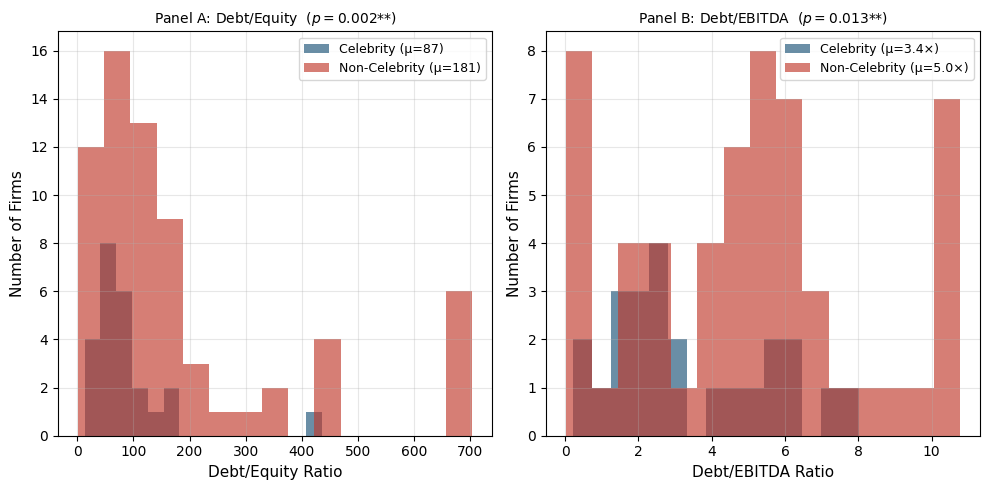


Saved → /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2/figure3_leverage_distribution.png
Figure 3 now matches Table 1 (Welch t-test p-values).
Remove the Mann-Whitney note from the Figure 3 caption in the LaTeX.


In [ ]:
# ============================================================
# STANDALONE CELL — Regenerate Figure 3
# Fixes: uses Welch t-test (matching Table 1) and dynamic
# significance stars instead of hardcoded **.
# Overwrites figure3_leverage_distribution.png on Drive.
# Run after drive.mount() — no other cells need to have run.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

OUT      = "/content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2"
CSV_PATH = f"{OUT}/cre_cgs.csv"
BLUE     = "#1a5276"
RED      = "#c0392b"
FIG_DPI  = 300

# ── Load data ────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
if "leverage" not in df.columns:
    df["leverage"] = (
        df["total_debt"] / df["ebitda"].abs()
    ).replace([np.inf, -np.inf], np.nan)

cel   = df[df["celebrity"] == 1]
noncel = df[df["celebrity"] == 0]

def sig_stars(p):
    if p < 0.01:  return "**"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

# ── Panel A: Debt/Equity ─────────────────────────────────────
cel_de  = cel["de_ratio"].dropna()
ncel_de = noncel["de_ratio"].dropna()
cap_de  = np.percentile(pd.concat([cel_de, ncel_de]), 95)
cel_de  = cel_de.clip(upper=cap_de)
ncel_de = ncel_de.clip(upper=cap_de)
_, p_de = stats.ttest_ind(cel_de, ncel_de, equal_var=False)

# ── Panel B: Debt/EBITDA ─────────────────────────────────────
cel_lev  = cel["leverage"].dropna()
ncel_lev = noncel["leverage"].dropna()
cap_lev  = np.percentile(pd.concat([cel_lev, ncel_lev]), 95)
cel_lev  = cel_lev.clip(upper=cap_lev)
ncel_lev = ncel_lev.clip(upper=cap_lev)
_, p_lev = stats.ttest_ind(cel_lev, ncel_lev, equal_var=False)

print(f"Welch t-test p-values:")
print(f"  Debt/Equity:  p = {p_de:.3f} {sig_stars(p_de)}")
print(f"  Debt/EBITDA:  p = {p_lev:.3f} {sig_stars(p_lev)}")

# ── Generate figure ──────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(10, 5))

# Panel A
axes3[0].hist(cel_de,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_de.mean():.0f})")
axes3[0].hist(ncel_de, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_de.mean():.0f})")
axes3[0].set_xlabel("Debt/Equity Ratio", fontsize=11)
axes3[0].set_ylabel("Number of Firms", fontsize=11)
axes3[0].set_title(
    f"Panel A: Debt/Equity  "
    f"($p={p_de:.3f}${sig_stars(p_de)})",
    fontsize=10)
axes3[0].legend(fontsize=9)
axes3[0].grid(alpha=0.3)

# Panel B
axes3[1].hist(cel_lev,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_lev.mean():.1f}×)")
axes3[1].hist(ncel_lev, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_lev.mean():.1f}×)")
axes3[1].set_xlabel("Debt/EBITDA Ratio", fontsize=11)
axes3[1].set_ylabel("Number of Firms", fontsize=11)
axes3[1].set_title(
    f"Panel B: Debt/EBITDA  "
    f"($p={p_lev:.3f}${sig_stars(p_lev)})",
    fontsize=10)
axes3[1].legend(fontsize=9)
axes3[1].grid(alpha=0.3)

fig3.tight_layout()
fig3.savefig(f"{OUT}/figure3_leverage_distribution.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show()
plt.close(fig3)

print(f"\nSaved → {OUT}/figure3_leverage_distribution.png")
print("Figure 3 now matches Table 1 (Welch t-test p-values).")
print("Remove the Mann-Whitney note from the Figure 3 caption in the LaTeX.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Welch t-test p-values (raw data — matches Table 1):
  Debt/Equity:  p = 0.027 **
  Debt/EBITDA:  p = 0.028 **


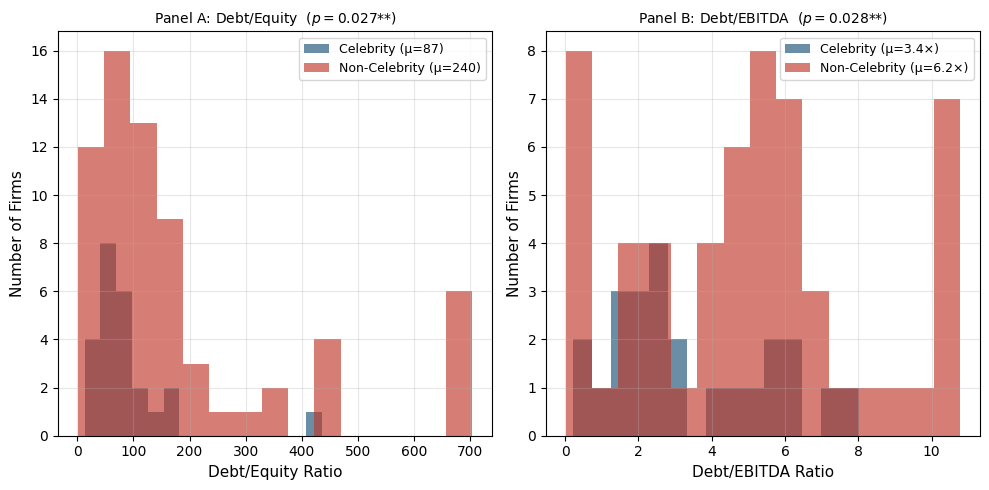


Saved → /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2/figure3_leverage_distribution.png
Figure 3 p-values now match Table 1 exactly.


In [ ]:
# ============================================================
# STANDALONE CELL — Regenerate Figure 3 (corrected)
#
# Fix: p-values computed on RAW (unclipped) data to match
# Table 1. The 95th percentile cap is kept for visual display
# only — it does not affect the reported statistics.
#
# Run after drive.mount() — no other cells need to have run.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

OUT      = "/content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2"
CSV_PATH = f"{OUT}/cre_cgs.csv"
BLUE     = "#1a5276"
RED      = "#c0392b"
FIG_DPI  = 300

# ── Load data ────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
if "leverage" not in df.columns:
    df["leverage"] = (
        df["total_debt"] / df["ebitda"].abs()
    ).replace([np.inf, -np.inf], np.nan)

cel    = df[df["celebrity"] == 1]
noncel = df[df["celebrity"] == 0]

def sig_stars(p):
    if p < 0.01:  return "**"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

# ── RAW data for p-values (matches Table 1) ──────────────────
cel_de_raw   = cel["de_ratio"].dropna()
ncel_de_raw  = noncel["de_ratio"].dropna()
_, p_de      = stats.ttest_ind(cel_de_raw, ncel_de_raw, equal_var=False)

cel_lev_raw  = cel["leverage"].dropna()
ncel_lev_raw = noncel["leverage"].dropna()
_, p_lev     = stats.ttest_ind(cel_lev_raw, ncel_lev_raw, equal_var=False)

print(f"Welch t-test p-values (raw data — matches Table 1):")
print(f"  Debt/Equity:  p = {p_de:.3f} {sig_stars(p_de)}")
print(f"  Debt/EBITDA:  p = {p_lev:.3f} {sig_stars(p_lev)}")

# ── CAPPED data for visual display only ──────────────────────
cap_de  = np.percentile(pd.concat([cel_de_raw,  ncel_de_raw]),  95)
cap_lev = np.percentile(pd.concat([cel_lev_raw, ncel_lev_raw]), 95)

cel_de_vis   = cel_de_raw.clip(upper=cap_de)
ncel_de_vis  = ncel_de_raw.clip(upper=cap_de)
cel_lev_vis  = cel_lev_raw.clip(upper=cap_lev)
ncel_lev_vis = ncel_lev_raw.clip(upper=cap_lev)

# ── Generate figure ──────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: Debt/Equity
axes3[0].hist(cel_de_vis,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_de_raw.mean():.0f})")
axes3[0].hist(ncel_de_vis, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_de_raw.mean():.0f})")
axes3[0].set_xlabel("Debt/Equity Ratio", fontsize=11)
axes3[0].set_ylabel("Number of Firms", fontsize=11)
axes3[0].set_title(
    f"Panel A: Debt/Equity  "
    f"($p={p_de:.3f}${sig_stars(p_de)})",
    fontsize=10)
axes3[0].legend(fontsize=9)
axes3[0].grid(alpha=0.3)

# Panel B: Debt/EBITDA
axes3[1].hist(cel_lev_vis,  bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_lev_raw.mean():.1f}×)")
axes3[1].hist(ncel_lev_vis, bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_lev_raw.mean():.1f}×)")
axes3[1].set_xlabel("Debt/EBITDA Ratio", fontsize=11)
axes3[1].set_ylabel("Number of Firms", fontsize=11)
axes3[1].set_title(
    f"Panel B: Debt/EBITDA  "
    f"($p={p_lev:.3f}${sig_stars(p_lev)})",
    fontsize=10)
axes3[1].legend(fontsize=9)
axes3[1].grid(alpha=0.3)

fig3.tight_layout()
fig3.savefig(f"{OUT}/figure3_leverage_distribution.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show()
plt.close(fig3)

print(f"\nSaved → {OUT}/figure3_leverage_distribution.png")
print("Figure 3 p-values now match Table 1 exactly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMRZ.SW']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-04-30) (Yahoo error = "Data doesn\'t exist for startDate = 1420066800, endDate = 1745964000")')


Generating Figure 1 ...


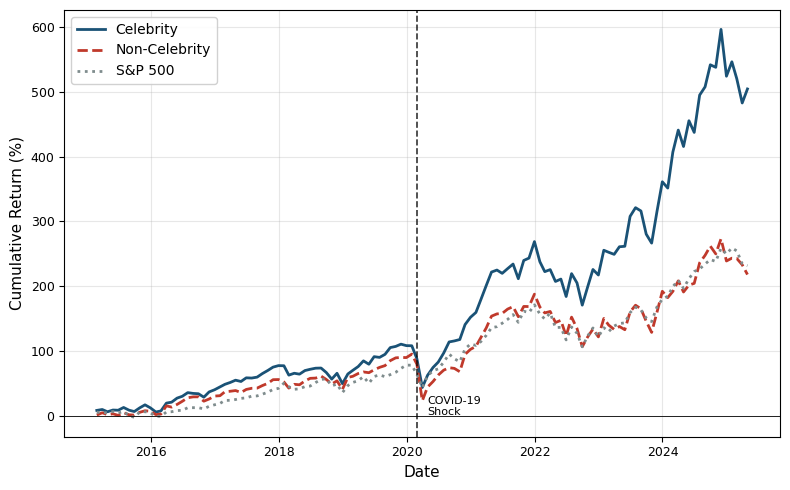

  Saved figure1_cumulative_returns.png
Generating Figure 3 ...


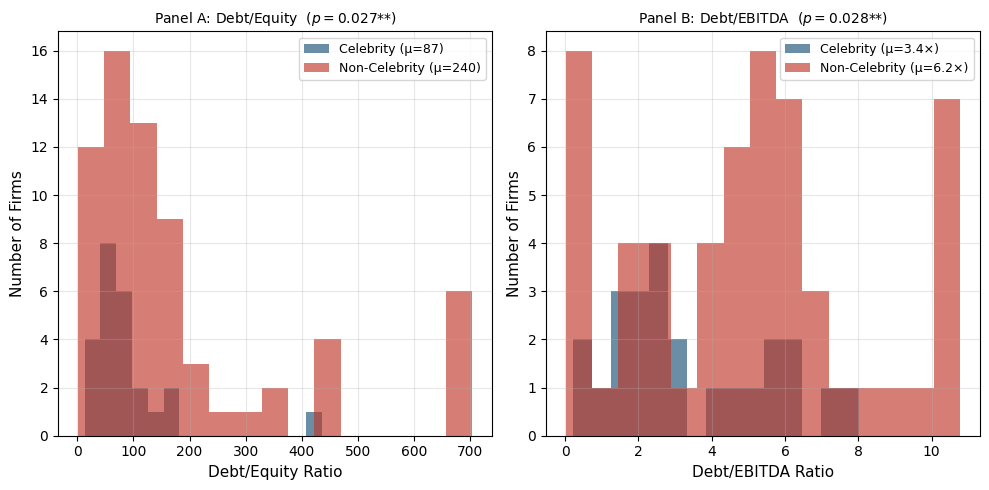

  Saved figure3_leverage_distribution.png

Done. Both figures saved to:
  /content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2

Now recompile your LaTeX — both figures will be correct.


In [ ]:
# ============================================================
# STANDALONE CELL — Regenerate Figure 1 and Figure 3
# Fixes:
#   Figure 1: S\&P 500 legend backslash removed
#   Figure 3: p-values from Welch on raw data (matches Table 1)
# Run after drive.mount() — no other cells needed.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

drive.mount("/content/drive", force_remount=False)

OUT      = "/content/drive/MyDrive/Russell3000_Diagnostic/full_study_v2"
CSV_PATH = f"{OUT}/cre_cgs.csv"
BLUE     = "#1a5276"
RED      = "#c0392b"
GREY     = "#7f8c8d"
FIG_DPI  = 300

PRE_START  = "2015-01-01"
POST_END   = "2025-04-30"

# ── Load firm data ───────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
if "leverage" not in df.columns:
    df["leverage"] = (
        df["total_debt"] / df["ebitda"].abs()
    ).replace([np.inf, -np.inf], np.nan)

cel_tickers  = df[df["celebrity"] == 1]["ticker"].tolist()
ncel_tickers = df[df["celebrity"] == 0]["ticker"].tolist()
all_tickers  = cel_tickers + ncel_tickers + ["SPY"]

cel    = df[df["celebrity"] == 1]
noncel = df[df["celebrity"] == 0]

print("Downloading returns for Figure 1 ...")
daily   = yf.download(all_tickers, start=PRE_START, end=POST_END,
                      auto_adjust=True, progress=False)["Close"]
monthly = daily.resample("ME").last().pct_change().dropna(how="all")

def ew_portfolio(tickers, df):
    cols = [t for t in tickers if t in df.columns]
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

def window(s, start, end):
    return s.loc[start:end].dropna()

ret_cel  = ew_portfolio(cel_tickers,  monthly)
ret_ncel = ew_portfolio(ncel_tickers, monthly)
ret_spy  = monthly["SPY"] if "SPY" in monthly.columns else pd.Series()

# ── FIGURE 1: Cumulative Returns ─────────────────────────────
print("Generating Figure 1 ...")
fig1, ax1 = plt.subplots(figsize=(8, 5))

for s, lbl, color, ls in [
    (ret_cel,  "Celebrity",     BLUE, "-"),
    (ret_ncel, "Non-Celebrity", RED,  "--"),
    (ret_spy,  "S&P 500",       GREY, ":"),   # fixed: no backslash
]:
    full = window(s, PRE_START, POST_END)
    cum  = (1 + full).cumprod() - 1
    ax1.plot(cum.index, cum * 100, label=lbl,
             color=color, linestyle=ls, linewidth=2.0)

ax1.axvline(pd.Timestamp("2020-03-01"), color="black",
            linewidth=1.2, linestyle="--", alpha=0.8)
ymin, ymax = ax1.get_ylim()
ax1.text(pd.Timestamp("2020-05-01"), ymin + (ymax - ymin) * 0.05,
         "COVID-19\nShock", fontsize=8, color="black")
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Cumulative Return (%)", fontsize=11)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.tick_params(labelsize=9)
fig1.tight_layout()
fig1.savefig(f"{OUT}/figure1_cumulative_returns.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show()
plt.close(fig1)
print("  Saved figure1_cumulative_returns.png")

# ── FIGURE 3: Leverage Distribution ─────────────────────────
print("Generating Figure 3 ...")

def sig_stars(p):
    if p < 0.01: return "**"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# p-values on RAW data (matches Table 1)
cel_de_raw   = cel["de_ratio"].dropna()
ncel_de_raw  = noncel["de_ratio"].dropna()
_, p_de      = stats.ttest_ind(cel_de_raw, ncel_de_raw, equal_var=False)

cel_lev_raw  = cel["leverage"].dropna()
ncel_lev_raw = noncel["leverage"].dropna()
_, p_lev     = stats.ttest_ind(cel_lev_raw, ncel_lev_raw, equal_var=False)

# Capped data for visual display only
cap_de  = np.percentile(pd.concat([cel_de_raw,  ncel_de_raw]),  95)
cap_lev = np.percentile(pd.concat([cel_lev_raw, ncel_lev_raw]), 95)

fig3, axes3 = plt.subplots(1, 2, figsize=(10, 5))

axes3[0].hist(cel_de_raw.clip(upper=cap_de),
              bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_de_raw.mean():.0f})")
axes3[0].hist(ncel_de_raw.clip(upper=cap_de),
              bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_de_raw.mean():.0f})")
axes3[0].set_xlabel("Debt/Equity Ratio", fontsize=11)
axes3[0].set_ylabel("Number of Firms", fontsize=11)
axes3[0].set_title(
    f"Panel A: Debt/Equity  ($p={p_de:.3f}${sig_stars(p_de)})",
    fontsize=10)
axes3[0].legend(fontsize=9)
axes3[0].grid(alpha=0.3)

axes3[1].hist(cel_lev_raw.clip(upper=cap_lev),
              bins=15, alpha=0.65, color=BLUE,
              label=f"Celebrity (μ={cel_lev_raw.mean():.1f}×)")
axes3[1].hist(ncel_lev_raw.clip(upper=cap_lev),
              bins=15, alpha=0.65, color=RED,
              label=f"Non-Celebrity (μ={ncel_lev_raw.mean():.1f}×)")
axes3[1].set_xlabel("Debt/EBITDA Ratio", fontsize=11)
axes3[1].set_ylabel("Number of Firms", fontsize=11)
axes3[1].set_title(
    f"Panel B: Debt/EBITDA  ($p={p_lev:.3f}${sig_stars(p_lev)})",
    fontsize=10)
axes3[1].legend(fontsize=9)
axes3[1].grid(alpha=0.3)

fig3.tight_layout()
fig3.savefig(f"{OUT}/figure3_leverage_distribution.png",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show()
plt.close(fig3)
print("  Saved figure3_leverage_distribution.png")

print(f"\nDone. Both figures saved to:\n  {OUT}")
print("\nNow recompile your LaTeX — both figures will be correct.")